# Gambler's Ruin
Gambler's ruin is a problem that is modeled using a on-dimensional random walk. Suppose a gambler enters a casino with $\$i$ and has the intention of playing a betting game to gain $\$N$ before going broke. The game has a probability $p$ to win $\$1$ and probability of $(1-p)$ of losing $\$1$.

This notebook analyzes the *Gambler's Ruin* problem.

## Part 1: Simulation
This first section simulates the problem with fixed values. The simulation takes the initial amount of money $i = \$5$, the gambler wants to gain $N = \$10$, and the probability of gaining $\$1$ from one play is $p = 0.5$. Given these parameters, the simulation tracks the fraction of times the gambler raches $\$N$.

In [125]:
import matplotlib.pyplot as plt
import numpy as np
import random

plt.style.use("ggplot")

In [126]:
# Parameters
p = 0.5
i = 5
N = 10

In [127]:
B = 10_000

def gambler_success_rate(start, target, prob):
    results = np.zeros(B)
    for b in range(B):
        curr = start

        # Simulate game until target or ruin
        while curr > 0 and curr < target:
            res = 1 if random.random() < prob else -1
            curr += res

        results[b] = curr

    game_results = np.where(results >= target, 1, 0)
    success = np.sum(game_results) / len(game_results)
    return float(success)

print(gambler_success_rate(i, N, p))

0.4974


As we can see from the simulation, given the initial parameters, the gambler has an approximately $50\%$ chance of reaching the target amount. Keeping $\$N$ fixed, the section below investigates how the gambler's success rate changes as a function of the starting amount $\$i$.

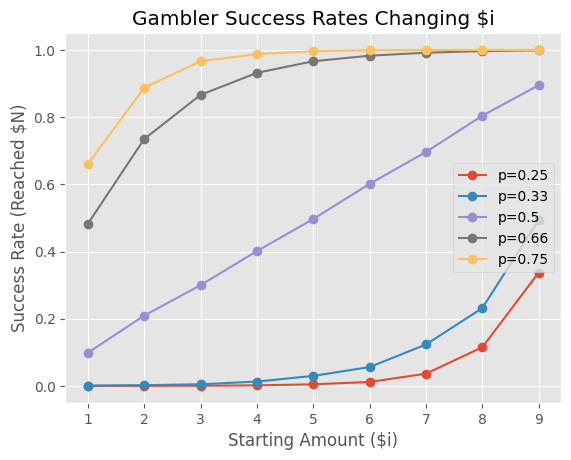

In [128]:
static_p = [0.25, 0.33, 0.50, 0.66, 0.75]
i_values = [a+1 for a in range(N-1)]

for s_p in static_p:
    successes = [
        gambler_success_rate(i_values[a], N, s_p)
        for a in range(len(i_values))
    ]

    # Plot the success rates for i and p
    plt.plot(i_values, successes, marker='o', label=f"p={s_p}")


plt.title("Gambler Success Rates Changing $i")
plt.xlabel("Starting Amount ($i)")
plt.ylabel("Success Rate (Reached $N)")
plt.legend()
plt.show()

Keeping the target and win probability constant when $p = 0.5$, there is almost a direct linear relationship between the starting amount $\$i$ and the chance of reaching the target $\$N$. This makes intuitive sense. If the gambler starts with an initial amount $\$i$ close to $\$N$, the probability of reaching $N$ approaches $1$.

Across all values of $p$, a higher starting value $\$i$ leads to a higher target success rate.

Instead of varying $\$i$, the section below varies $p$. This investigates how the probability of reaching $\$N$ changes as a function of the win probability $p$. This keeps $\$i = 5$ and $\$N = 10$ constant.

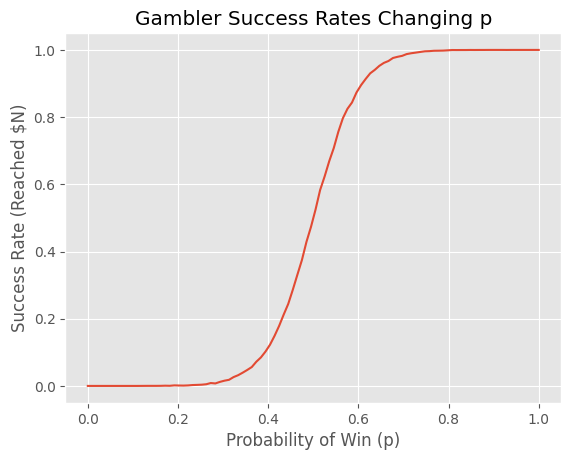

In [129]:
p_values = np.linspace(0, 1, 100)
successes = [
    gambler_success_rate(i, N, p_values[a])
    for a in range(len(p_values))
]

plt.plot(p_values, successes)
plt.title("Gambler Success Rates Changing p")
plt.xlabel("Probability of Win (p)")
plt.ylabel("Success Rate (Reached $N)")
plt.show()

Compared to changing the initial amounts, the relationship between the probability of win $p$ and the gambler's success rate behaves like a sigmoid function. When the probability of a win is low, the corresponding success rate is also low (indicating the gambler faces ruin!). As the probability of winning increases, the gambler's success rate increases and plateus at 1 (certianty of winning). By observing the variation of $\$i$ and $p$, we can understand that the gambler only gains an advantage (success rate of raching $\$N$), when the probability of a win is higher.